<a href="https://colab.research.google.com/github/aliraza0321/neurofive-solutions-ML-internship/blob/main/Task_8_Random_Forest_vs_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [1]:
pip install xgboost


In [10]:
import xgboost as xgb

In [3]:
df=pd.read_csv("Telco-Customer-Churn.csv") # Load the dataset into a pandas DataFrame

In [4]:
print(df.head()) # Display the first 5 rows of the DataFrame
print(df.info()) # Print a summary of the DataFrame including data types and non-null values

   customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0  7590-VHVEG  Female              0  ...          29.85        29.85     No
1  5575-GNVDE    Male              0  ...          56.95       1889.5     No
2  3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3  7795-CFOCW    Male              0  ...          42.30      1840.75     No
4  9237-HQITU  Female              0  ...          70.70       151.65    Yes

[5 rows x 21 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-

In [5]:
df=df.drop(["customerID"],axis=1) # Drop the 'customerID' column as it's not needed for modeling
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Convert 'TotalCharges' to numeric, coercing errors to NaN

print(df['TotalCharges'].isnull().sum()) # Check for the number of null values in 'TotalCharges'

df['TotalCharges'] = df['TotalCharges'].fillna(0) # Fill missing 'TotalCharges' with 0

11


In [6]:
#handle categorical values and target

df['Churn']=df['Churn'].map({'Yes':1,'No':0}) # Convert 'Churn' target variable to numerical (1 for Yes, 0 for No)

X=df.drop(['Churn'],axis=1) # Separate features (X) from the target variable (y)
y=df['Churn']

X=pd.get_dummies(X) # Apply one-hot encoding to all categorical features in X

In [7]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) # Split data into training and testing sets

scaler=StandardScaler() # Initialize StandardScaler
x_train=scaler.fit_transform(x_train) # Fit scaler on training data and transform it
x_test=scaler.transform(x_test) # Transform test data using the same scaler

In [15]:
model1=RandomForestClassifier() # Initialize Random Forest Classifier

model2=xgb.XGBClassifier( # Initialize XGBoost Classifier with specified hyperparameters
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100,
    objective='binary:logistic',
    random_state=42


)

model1.fit(x_train,y_train) # Train Random Forest model
model2.fit(x_train,y_train) # Train XGBoost model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred1=model1.predict(x_test) # Make predictions with Random Forest model
y_pred2=model2.predict(x_test) # Make predictions with XGBoost model

accuracy1=accuracy_score(y_test,y_pred1) # Calculate accuracy for Random Forest
accuracy2=accuracy_score(y_test,y_pred2) # Calculate accuracy for XGBoost

In [17]:
print("Random Forest Accuracy:",accuracy1) # Print Random Forest accuracy
print("XGBoost Accuracy:",accuracy2) # Print XGBoost accuracy

Random Forest Accuracy: 0.8005677785663591
XGBoost Accuracy: 0.8133427963094393


In [18]:
import matplotlib.pyplot as plt



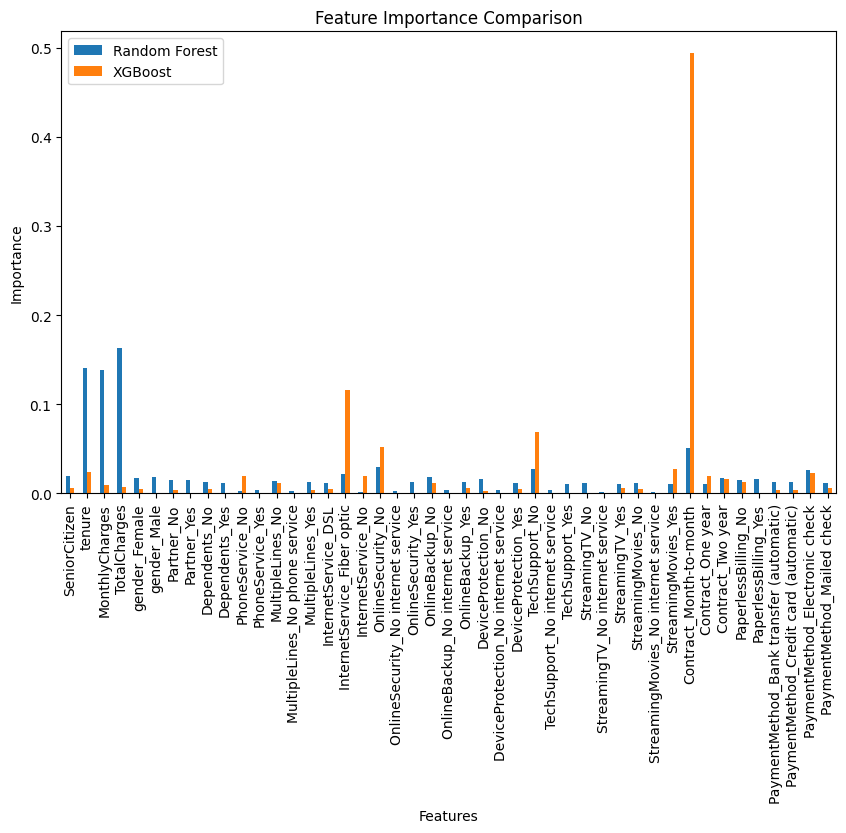

In [19]:
rf_importance=model1.feature_importances_ # Get feature importances from Random Forest
xbg_importance=model2.feature_importances_ # Get feature importances from XGBoost

df_importance=pd.DataFrame(
    {
      'Random Forest':rf_importance,
     'XGBoost':xbg_importance
    }
    ,index=X.columns) # Create a DataFrame for comparing feature importances

df_importance.plot(kind='bar',figsize=(10,6)) # Plot the feature importances
plt.xlabel('Features') # Set x-axis label
plt.ylabel('Importance') # Set y-axis label
plt.title('Feature Importance Comparison') # Set plot title
plt.show() # Display the plot

In [20]:
"""
Random Forest has less accuracy than xgb
xgb has higher accuracy .
Random forest builds many trees that are working in parallel but
xgb run only sequential trees .
that is main difference btw both .
Random Forest primarily focuses model overfitting by averaging noisy trees,
XGBoost systematically minimizes both bias and variance using gradient optimization.
"""

'\nRandom Forest has less accuracy than xgb \nxgb has higher accuracy .\nRandom forest builds many trees that are working in parallel but \nxgb run only sequential trees .\nthat is main difference btw both .\nRandom Forest primarily focuses model overfitting by averaging noisy trees, \nXGBoost systematically minimizes both bias and variance using gradient optimization.\n'